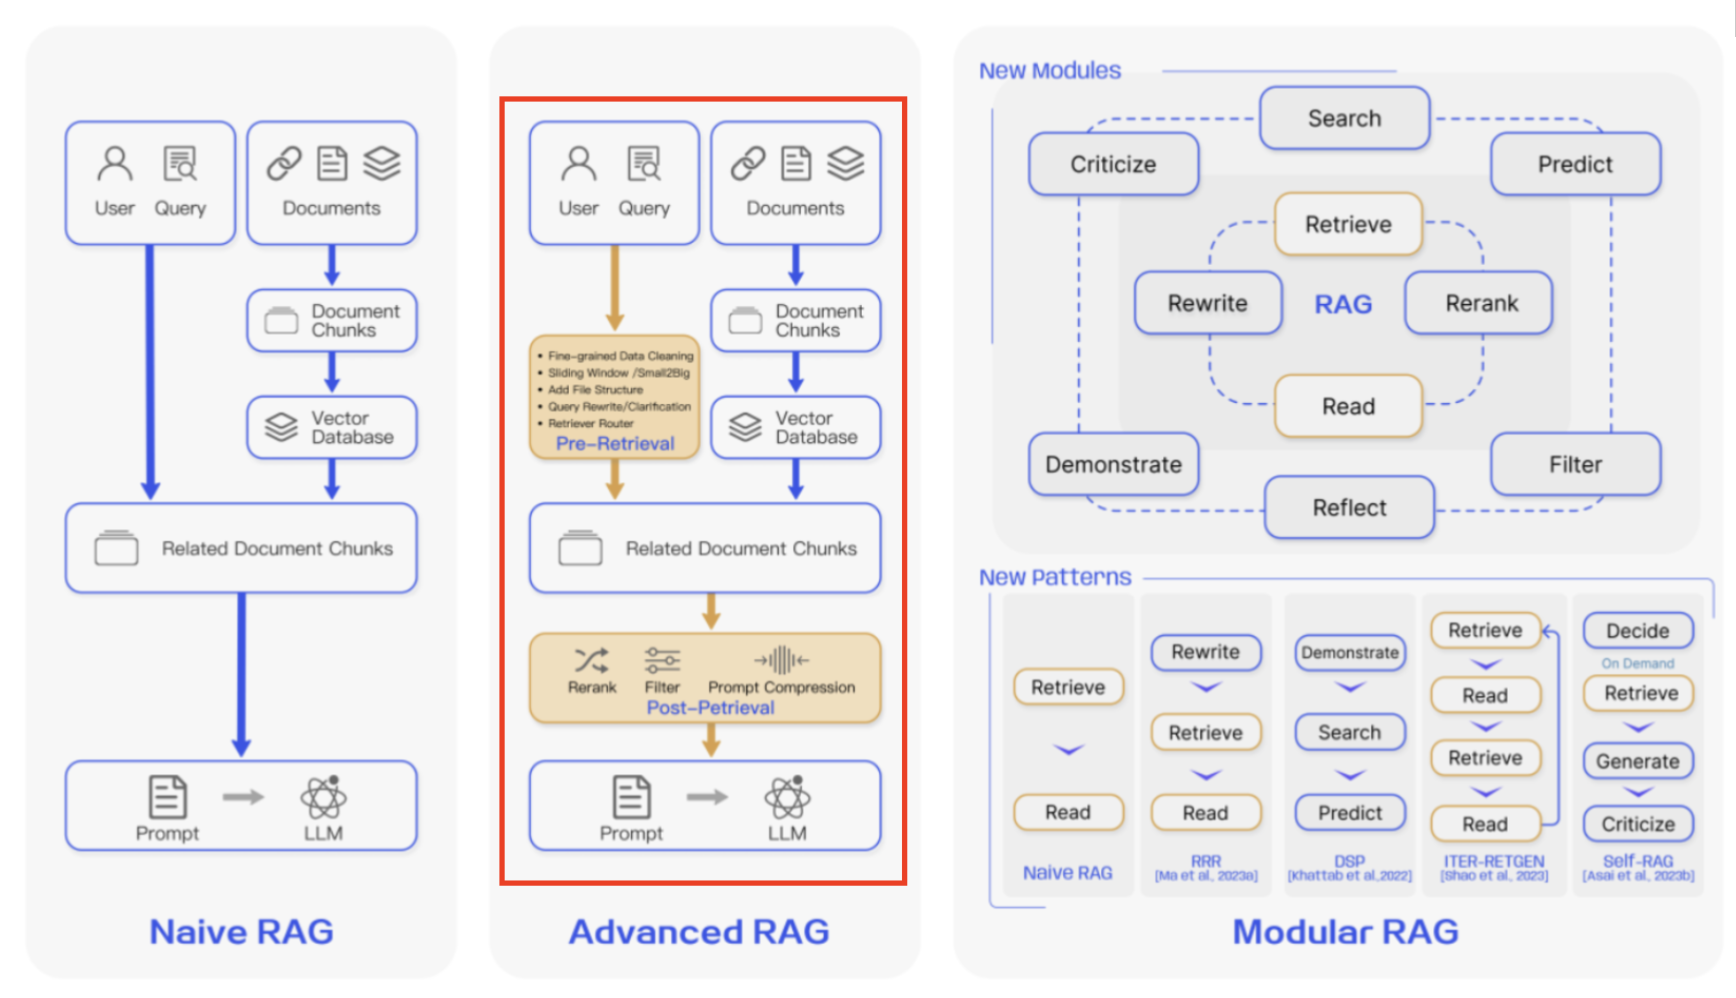

# [Elasticsearch VectorDB](https://www.elastic.co/elasticsearch/)


## 1. Elasticsearch란?
> Elasticsearch는 Apache Lucene 기반의 분산형 RESTful 검색 및 분석 엔진으로, 벡터 검색과 전통적인 키워드 검색을 모두 지원하는 강력한 데이터베이스입니다.


### 주요 특징
- **하이브리드 검색**: 벡터 검색(Semantic)과 키워드 검색(Lexical)을 동시에 지원
- **실시간 검색**: 준실시간(Near Real-Time) 검색 및 분석 기능
- **확장성**: 수평적 확장이 용이한 분산 아키텍처
- **RESTful API**: 직관적인 HTTP REST API 제공
- **강력한 분석 기능**: Kibana를 통한 시각화 및 대시보드
- **다양한 검색 전략**: Dense Vector, Sparse Vector(ELSER), BM25 등 지원


### 사용 사례
- 엔터프라이즈 검색 시스템
- 로그 및 이벤트 데이터 분석
- RAG (Retrieval Augmented Generation) 시스템
- 하이브리드 검색 (의미 검색 + 키워드 검색)
- 실시간 애플리케이션 성능 모니터링
- 전자상거래 상품 검색


## 2. Elasticsearch vs 다른 벡터 데이터베이스


### Elasticsearch의 장점
- **하이브리드 검색**: 벡터 검색과 전통적인 텍스트 검색을 동시에 활용 가능
- **성숙한 생태계**: Elastic Stack (Elasticsearch, Logstash, Kibana, Beats)의 풍부한 도구
- **강력한 분석**: 집계(Aggregation) 기능을 통한 복잡한 데이터 분석
- **검증된 안정성**: 수년간 운영된 엔터프라이즈급 안정성
- **다양한 배포 옵션**: Self-hosted, Elastic Cloud 등
- **실시간 업데이트**: 준실시간 인덱싱 및 검색


### 다른 솔루션과의 비교

| 특성 | Chroma | pgvector | Qdrant | Milvus | Elasticsearch |
|------|--------|----------|--------|--------|---------------|
| **복잡도** | 낮음 | 중간 | 중간 | 높음 | 중간 |
| **설정 난이도** | 매우 쉬움 | 쉬움 | 쉬움 | 어려움 | 중간 |
| **확장성** | 소규모 | 중규모 | 중대규모 | 대규모 | 대규모 |
| **검색 속도** | 보통 | 보통 | 빠름 | 매우 빠름 | 빠름 |
| **하이브리드 검색** | 제한적 | 가능 | 가능 | 가능 | **탁월함** |
| **분석 기능** | 없음 | 기본 | 제한적 | 제한적 | **매우 강력** |
| **생태계** | 신생 | PostgreSQL | 성장 중 | 성장 중 | **매우 성숙** |
| **운영 경험** | 부족 | 풍부 | 중간 | 중간 | **매우 풍부** |
| **메모리 효율** | 보통 | 좋음 | 좋음 | 매우 좋음 | 좋음 |
| **기존 데이터 통합** | 어려움 | **쉬움** | 중간 | 중간 | **쉬움** |

#### 선택 가이드
- **Chroma**: 빠른 프로토타이핑, 소규모 프로젝트
- **pgvector**: 기존 PostgreSQL 인프라 활용, 중간 규모
- **Qdrant**: 고성능 벡터 검색, 풍부한 필터링
- **Milvus**: 초대규모 벡터 데이터, 최고 성능 요구
- **Elasticsearch**: 하이브리드 검색, 복잡한 분석, 엔터프라이즈 환경, 기존 Elastic Stack 활용


### Elasticsearch 용어 

| RDB 개념          | Elasticsearch 대응 개념                                           | 설명                                                                          |
| --------------- | ------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **Database**    | **Index**                                                     | 데이터가 저장되는 최상위 논리 단위. RDB의 Database와 가장 유사.                                  |
| **Table**       | **(Type)** → *Deprecated*<br>**→ 사실상 Index 하나가 하나의 Table 역할** | 과거에는 하나의 Index 안에 여러 Type이 존재했지만, Type은 폐지됨. 현재는 **Index = Table** 개념으로 사용. |
| **Column**      | **Field**                                                     | 문서(document)의 속성. RDB의 컬럼과 동일한 역할. 각 필드는 타입(text, keyword, integer 등)을 가짐.  |
| **Row**         | **Document**                                                  | 인덱스에 저장되는 실제 데이터. JSON 객체 형태.                                               |
| **Primary Key** | **_id**                                                       | 문서를 식별하는 고유 ID. 명시하지 않으면 ES가 자동 생성.                                         |


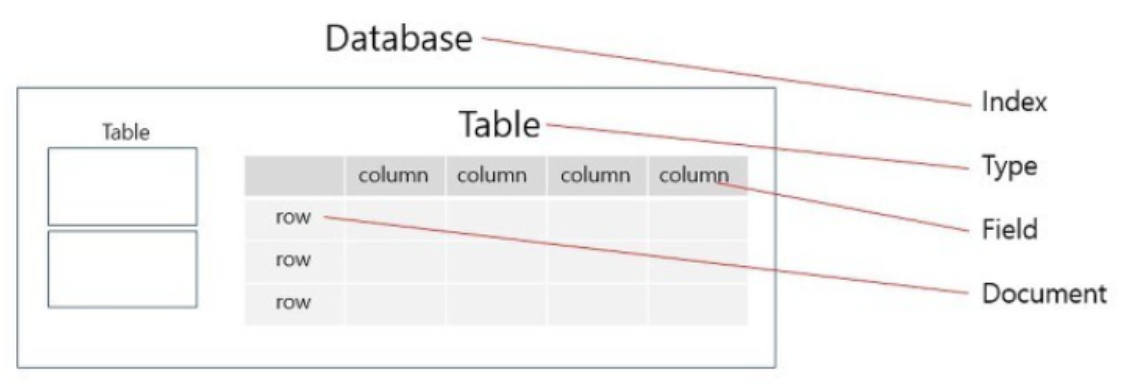

## 3. 설치 및 설정

Elasticsearch를 Docker Compose를 사용하여 설치하겠습니다.


### 3.1 Docker Compose로 Elasticsearch 실행

`elasticsearch/docker-compose.yml` 파일을 사용하여 Elasticsearch와 Kibana를 실행합니다.

```bash
cd elasticsearch
docker-compose up -d
```


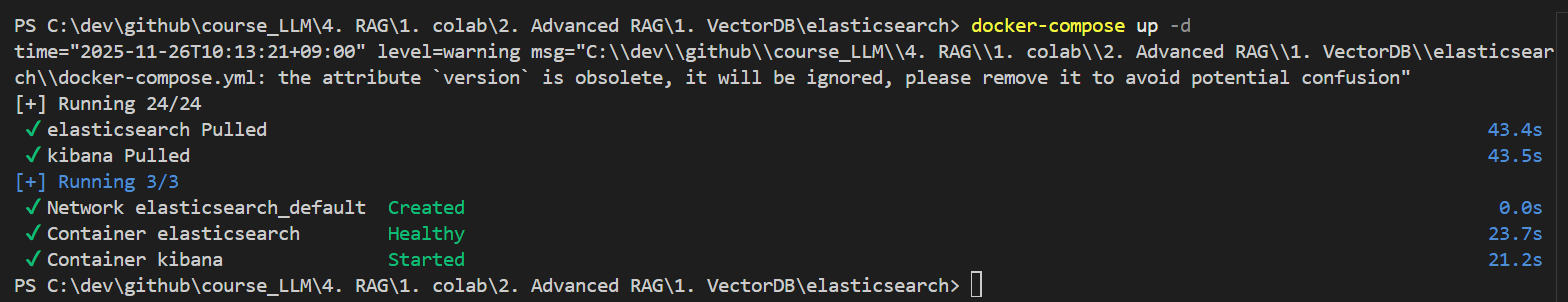

### 3.2 Elasticsearch 연결 확인
- Elasticsearch REST API: http://localhost:9200
- id:`elastic` & pw:`changeme123!`

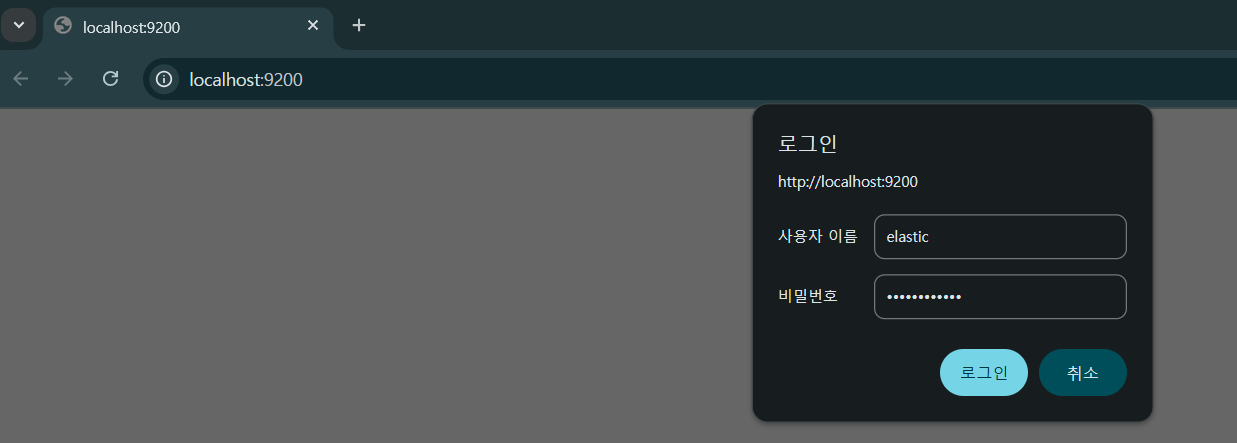

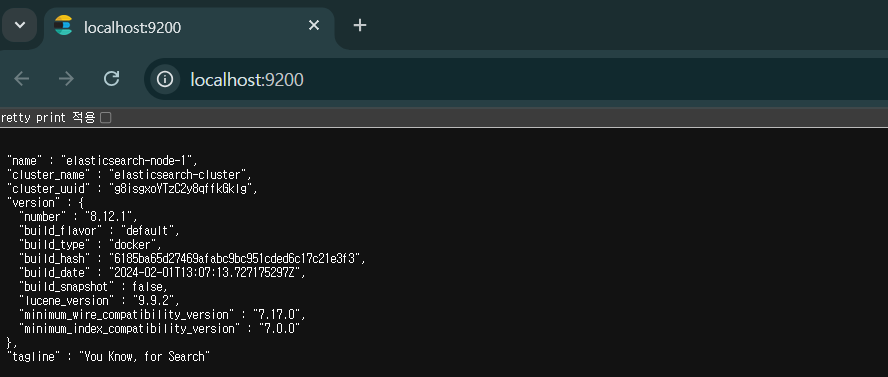

In [1]:
# Elasticsearch Python 클라이언트 라이브러리 import
from elasticsearch import Elasticsearch
import warnings

# 개발 환경에서 SSL 경고 메시지 무시 설정
warnings.filterwarnings('ignore')

# Elasticsearch 클라이언트 객체 생성 및 연결
# elasticsearch 9.x 버전부터는 명시적으로 http/https scheme 지정 필요
try:
    es_client = Elasticsearch(
        ["http://localhost:9200"],  # Elasticsearch 서버 주소 (리스트 형태, scheme 포함)
        basic_auth=("elastic", "changeme123!"),  # 인증 정보 (사용자명, 비밀번호)
        verify_certs=False,          # SSL 인증서 검증 비활성화 (개발 환경용)
        ssl_show_warn=False,         # SSL 경고 메시지 비활성화
        request_timeout=30,          # 요청 타임아웃 시간 (초 단위)
        max_retries=3,               # 연결 실패 시 최대 재시도 횟수
        retry_on_timeout=True,       # 타임아웃 발생 시 자동 재시도 활성화
        # HTTP 요청 헤더 설정 (JSON 형식으로 통신)
        headers={"accept": "application/json", "content-type": "application/json"}
    )
    
    # Elasticsearch 서버 연결 상태 확인 (ping)
    if es_client.ping():
        print("Elasticsearch 연결 성공!")
        print()
        
        # 연결된 Elasticsearch 클러스터 정보 조회
        info = es_client.info()
        print(f"버전: {info['version']['number']}")
        print(f"클러스터 이름: {info['cluster_name']}")
        print(f"노드 이름: {info['name']}")
        print()
        print(f"Elasticsearch URL: http://localhost:9200")
    else:
        print("Elasticsearch 연결 실패 (ping 실패)")
        
except Exception as e:
    # 연결 중 예외 발생 시 에러 정보 출력
    print("Elasticsearch 연결 중 오류 발생:")
    print(f"   에러 타입: {type(e).__name__}")
    print(f"   에러 메시지: {str(e)}")

Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1

Elasticsearch URL: http://localhost:9200


### 3.3 Kibana Web UI
> Kibana를 통해 Elasticsearch를 시각적으로 관리할 수 있습니다.

로그인 정보:
- 로그인 페이지: http://localhost:5601
- Username: elastic
- Password: changeme123!

주요 기능:
- Dev Tools: Elasticsearch API를 직접 테스트
- Discover: 데이터 탐색 및 검색
- Dashboard: 데이터 시각화
- Index Management: 인덱스 관리

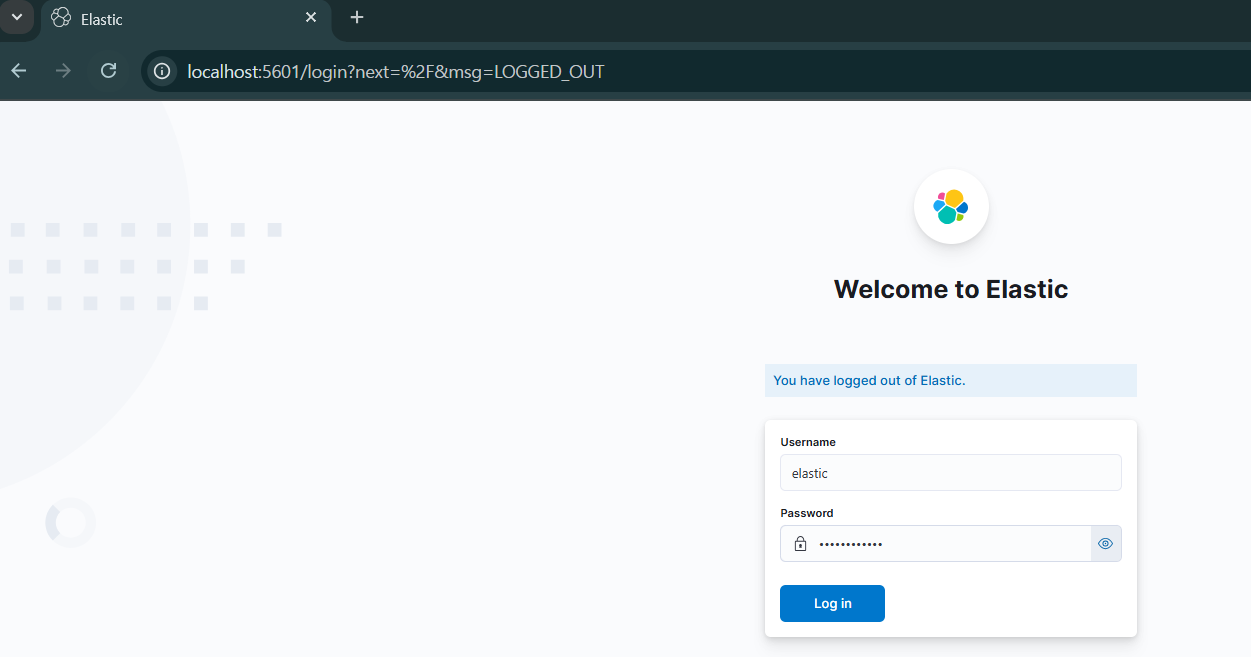

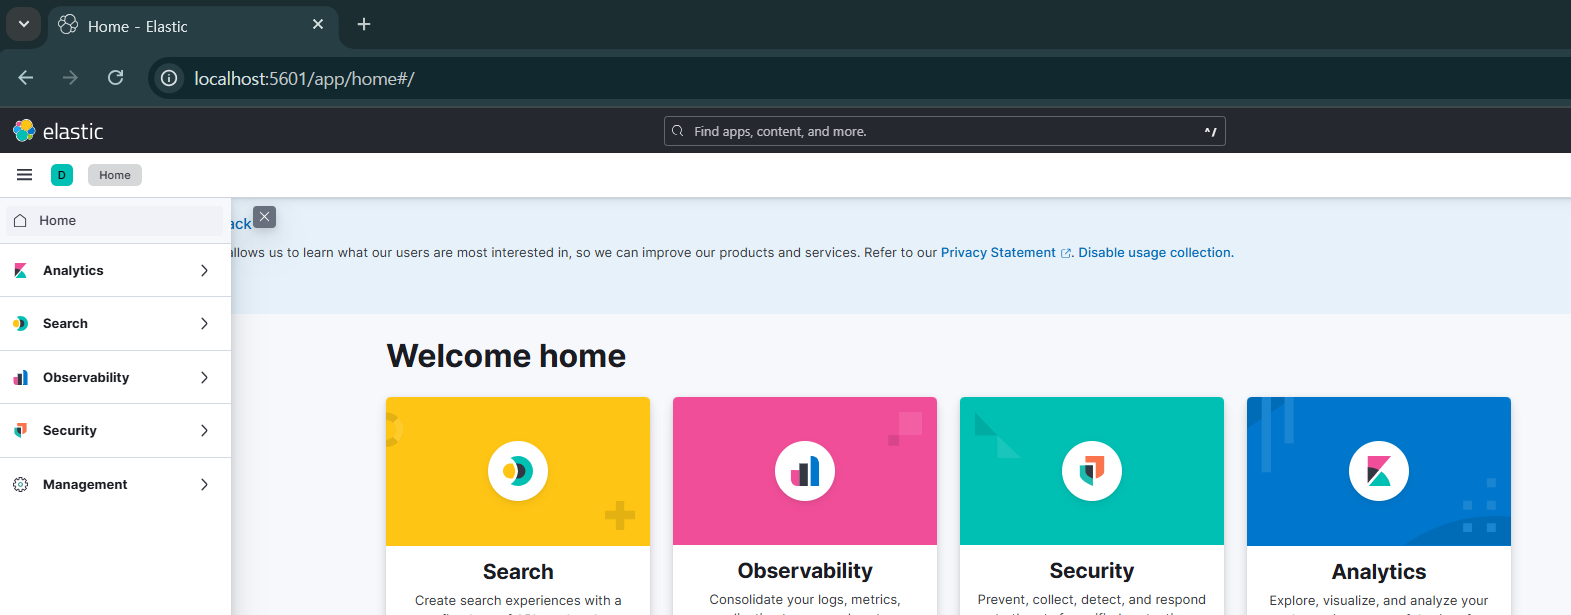

## 4. Elasticsearch를 이용한 벡터 데이터 저장


### 4.1 텍스트 파일 로드


In [2]:
# LangChain의 텍스트 파일 로더 import
from langchain_community.document_loaders import TextLoader

# 텍스트 파일을 읽어서 Document 객체로 변환
# encoding="utf-8": 한글 등 유니코드 문자를 제대로 읽기 위한 인코딩 설정
loader = TextLoader("./data/rag-keywords.txt", encoding="utf-8")
# load(): 파일 내용을 Document 객체 리스트로 반환
documents = loader.load()
print(f"파일 로드 완료: {len(documents)}개 문서")


파일 로드 완료: 1개 문서


### 4.2 텍스트 분할


In [3]:
# LangChain의 재귀적 문자 기반 텍스트 분할기 import
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 텍스트를 작은 청크(조각)으로 분할하는 splitter 설정
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,      # 각 청크의 최대 문자 수 (200자)
    chunk_overlap=50     # 청크 간 중복되는 문자 수 (문맥 유지를 위해 50자 겹침)
)

# 로드한 문서를 설정된 크기로 분할
# 긴 문서를 작은 조각으로 나누면 검색 정확도가 향상됨
splits = text_splitter.split_documents(documents)
print(f"텍스트 분할 완료: {len(splits)}개 청크")


텍스트 분할 완료: 41개 청크


### 4.3 임베딩 모델 설정


In [4]:
# LangChain의 Ollama 임베딩 모델을 사용하기 위한 import
from langchain_ollama import OllamaEmbeddings

# Ollama의 qwen3-embedding 모델 초기화
# 텍스트를 1024차원의 벡터로 변환하는 임베딩 모델
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


### 4.4 벡터 인덱스 생성


In [5]:
# Elasticsearch에 생성할 인덱스 이름 정의
# 인덱스는 RDB의 Database나 Table과 유사한 개념
index_name = "rag_keywords"

# 동일한 이름의 인덱스가 이미 존재하는지 확인
if es_client.indices.exists(index=index_name):
    # 기존 인덱스 삭제 (새롭게 시작하기 위해)
    es_client.indices.delete(index=index_name)
    print(f"기존 인덱스 '{index_name}' 삭제")

# 인덱스의 필드(스키마) 구조를 정의하는 매핑 생성
# qwen3-embedding:0.6b 모델은 1024차원의 벡터를 생성
index_mapping = {
    "mappings": {
        "properties": {
            # text 필드: 원본 텍스트를 저장하고 전문 검색(Full-text search) 지원
            "text": {
                "type": "text",              # 텍스트 타입 (분석 및 토큰화됨)
                "analyzer": "standard"       # 표준 분석기 사용 (공백 및 구두점 기준 분리)
            },
            # embedding 필드: 텍스트의 벡터 표현을 저장
            "embedding": {
                "type": "dense_vector",      # 밀집 벡터 타입 (벡터 검색용)
                "dims": 1024,                # 벡터 차원 수 (임베딩 모델에 따라 조정 필요)
                "index": True,               # 벡터 인덱스 생성 활성화 (검색 성능 향상)
                "similarity": "cosine"       # 유사도 측정 방식: 코사인 유사도 (-1 ~ 1)
            },
            # metadata 필드: 문서의 메타데이터 (출처, 날짜 등) 저장
            "metadata": {
                "type": "object",            # JSON 객체 타입
                "enabled": True              # 필드 활성화 (검색 및 저장 가능)
            }
        }
    }
}

# 정의한 매핑으로 Elasticsearch 인덱스 생성
es_client.indices.create(index=index_name, body=index_mapping)
print(f"인덱스 '{index_name}' 생성 완료")


인덱스 'rag_keywords' 생성 완료


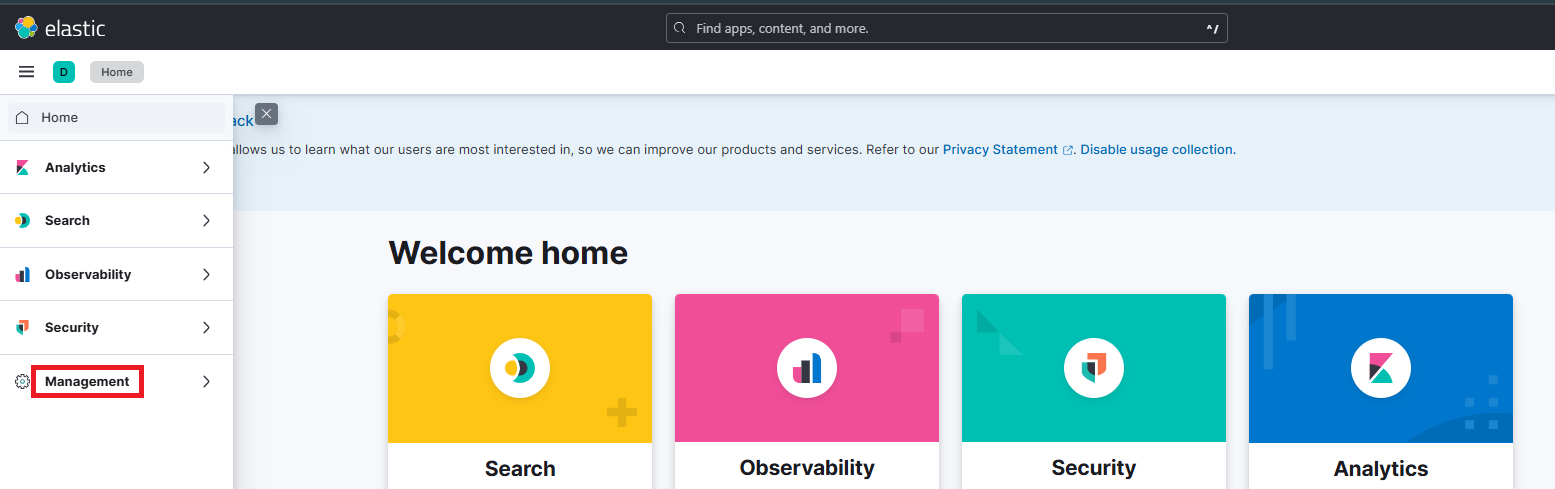

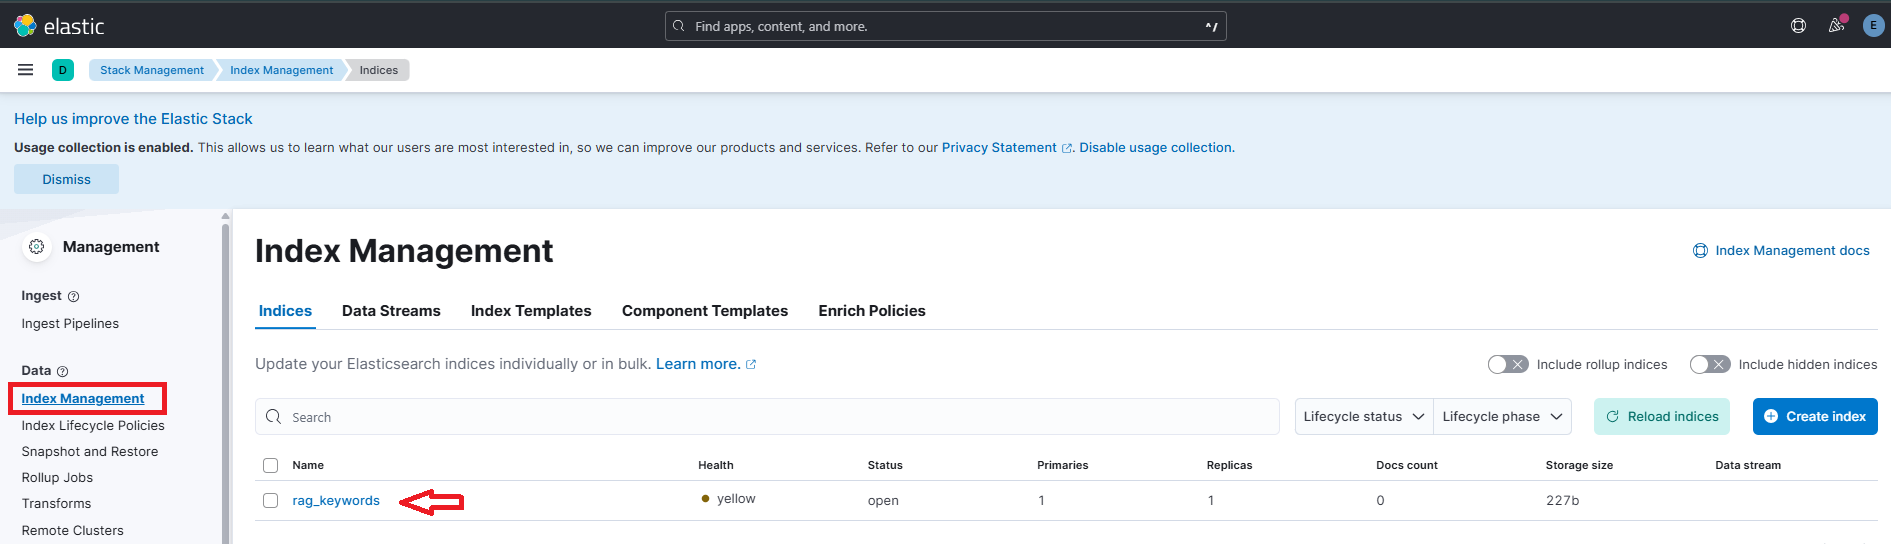

### 4.5 문서 임베딩 및 인덱싱


In [6]:
# Elasticsearch 대량 작업을 위한 bulk 헬퍼 함수 import
from elasticsearch.helpers import bulk

# 분할된 문서들에서 텍스트 내용만 추출
texts = [doc.page_content for doc in splits]
# 추출한 텍스트들을 임베딩 모델로 벡터화
# embed_documents: 여러 문서를 한 번에 벡터로 변환
embeddings_list = embeddings.embed_documents(texts)

print(f"임베딩 생성 완료: {len(embeddings_list)}개")
print(f"임베딩 차원: {len(embeddings_list[0])}")

# Elasticsearch에 대량 삽입할 문서들을 생성하는 제너레이터 함수
def generate_docs():
    # 문서와 임베딩을 쌍으로 묶어서 순회
    for i, (doc, embedding) in enumerate(zip(splits, embeddings_list)):
        # Elasticsearch bulk API 형식에 맞춰 문서 생성
        yield {
            "_index": index_name,           # 저장할 인덱스 이름
            "_id": i,                       # 문서 고유 ID
            "_source": {                    # 실제 저장될 문서 데이터
                "text": doc.page_content,   # 원본 텍스트
                "embedding": embedding,      # 벡터 임베딩
                "metadata": doc.metadata    # 메타데이터 (출처 등)
            }
        }

# Elasticsearch에 벌크(대량) 인덱싱 실행
# bulk: 여러 문서를 한 번에 효율적으로 삽입
success, failed = bulk(es_client, generate_docs())
print(f"인덱싱 완료: {success}개 성공")

# 인덱스 새로고침 (메모리의 데이터를 검색 가능하도록 디스크에 동기화)
# Elasticsearch는 준실시간(Near Real-Time) 검색을 제공하므로 명시적 refresh 필요
es_client.indices.refresh(index=index_name)

# 인덱스에 저장된 총 문서 수 확인
count = es_client.count(index=index_name)['count']
print(f"저장된 문서 수: {count}개")


임베딩 생성 완료: 41개
임베딩 차원: 1024
인덱싱 완료: 41개 성공
저장된 문서 수: 41개


> Docs count를 통해 데이터가 41개 저장된 것을 확인할 수 있음 

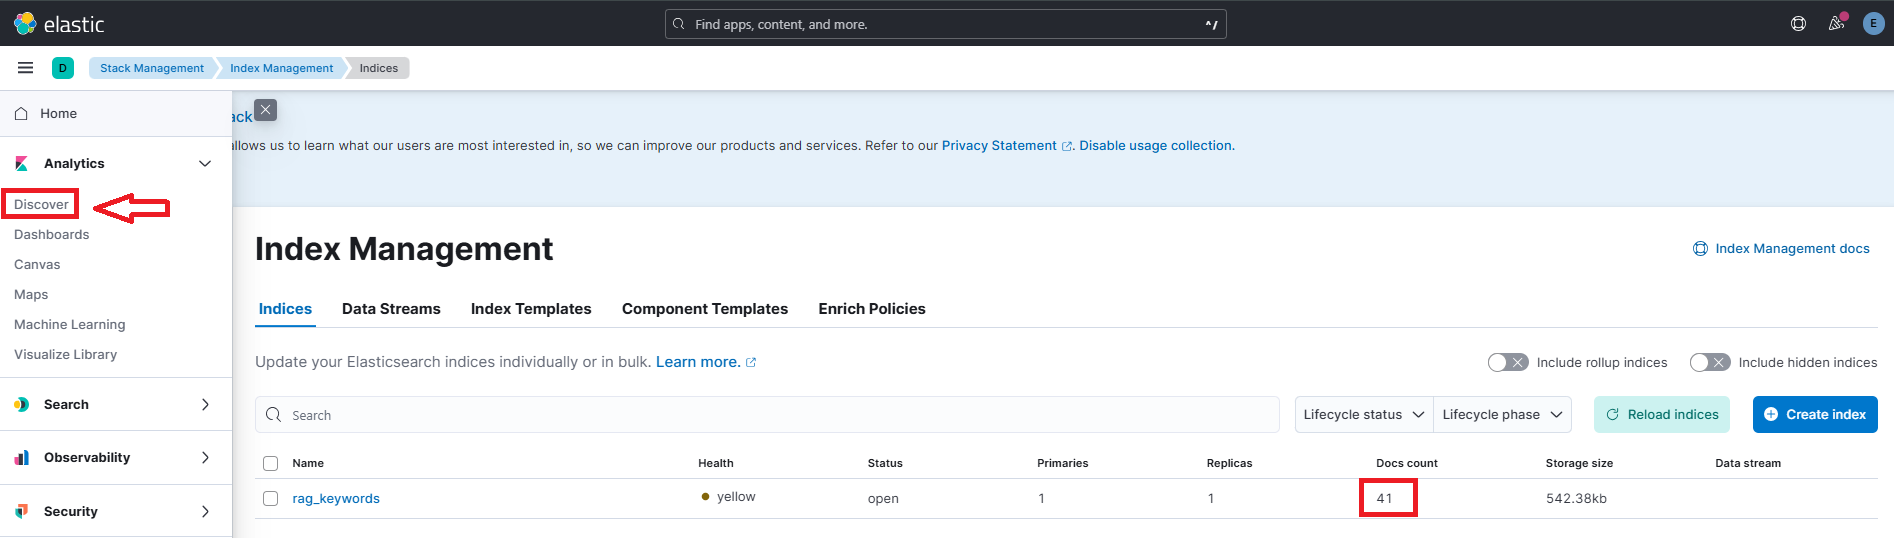

> Discover를 이용해서 데이터 확인하기 

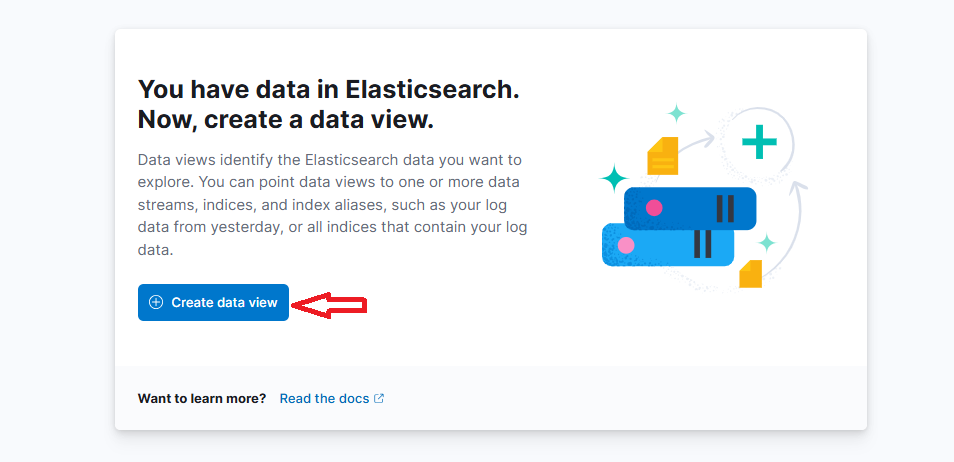

> index pattern의 데이터는 `인덱스 이름` + `*` 와 같이 응용해서 생성 

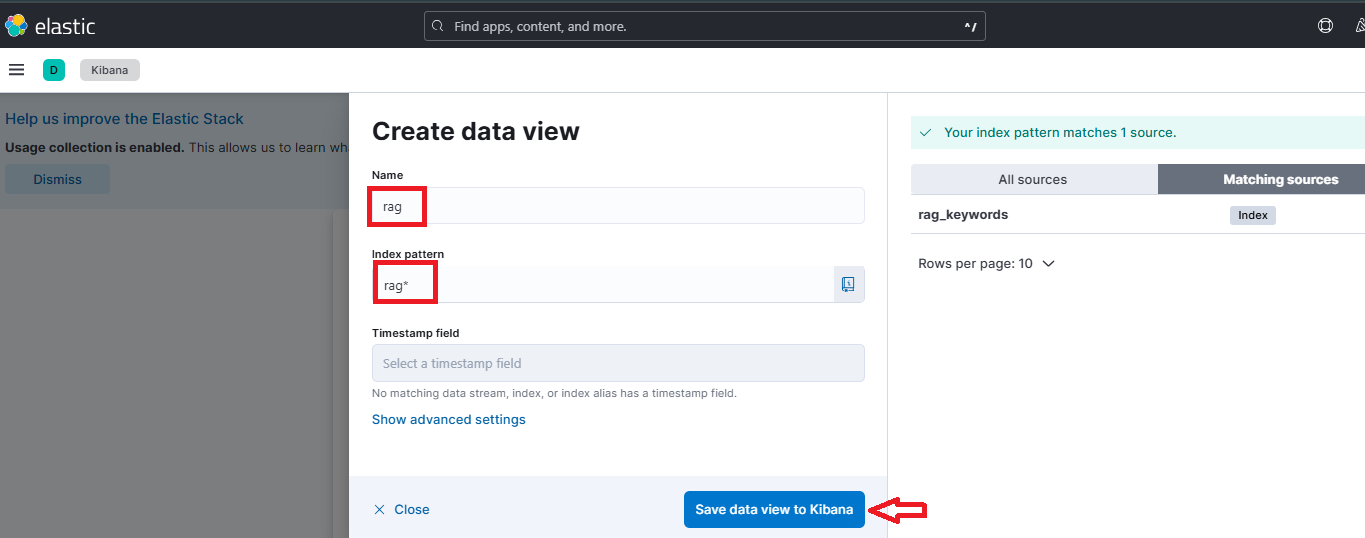

> 데이터 조회 예시 

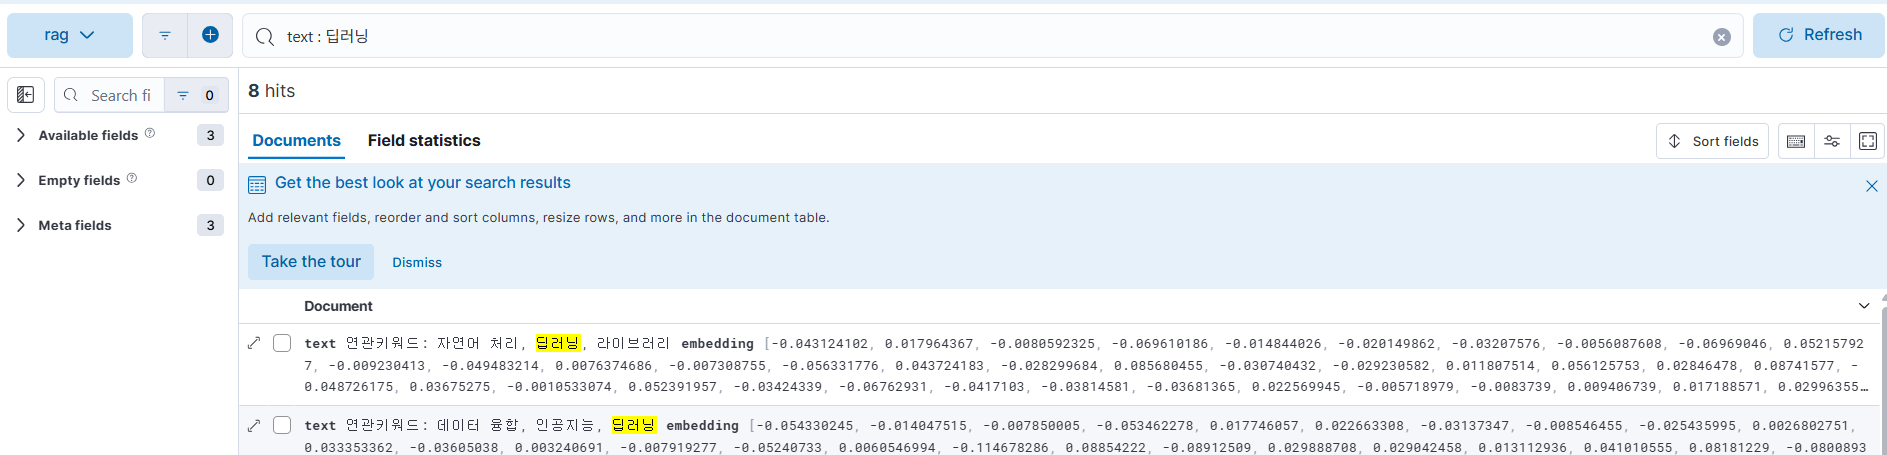

## 5. Elasticsearch를 이용한 벡터 검색 
elasticsearch 모듈을 직접 사용하여 벡터 검색을 구현합니다.

### 5.1 BM25 키워드 검색 (벡터 검색 없이)

In [7]:
def keyword_search(query_text, k=3, index_name="rag_keywords"):
    """
    BM25 알고리즘 기반 키워드 검색 (전통적인 전문 검색)
    벡터 검색 없이 텍스트 매칭만으로 관련 문서 찾기
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트 (텍스트, 메타데이터, BM25 점수 포함)
    """
    # BM25 검색 쿼리 구성
    # BM25: 용어 빈도(TF)와 역문서 빈도(IDF)를 기반으로 한 랭킹 알고리즘
    search_query = {
        "query": {
            "match": {                    # match 쿼리: 텍스트 분석 후 토큰 매칭
                "text": query_text        # text 필드에서 쿼리 텍스트와 매칭
            }
        },
        "size": k,                        # 반환할 결과 개수
        "_source": ["text", "metadata"]   # 결과에 포함할 필드 지정
    }
    
    # Elasticsearch에 검색 요청 실행
    response = es_client.search(index=index_name, body=search_query)
    
    # 검색 결과를 파싱하여 리스트로 변환
    results = []
    for hit in response['hits']['hits']:  # 각 검색 결과(hit) 순회
        results.append({
            'text': hit['_source']['text'],                  # 문서 텍스트
            'metadata': hit['_source'].get('metadata', {}),  # 메타데이터 (없으면 빈 딕셔너리)
            'score': hit['_score']                           # BM25 점수 (높을수록 관련성↑)
        })
    
    return results


In [8]:
# BM25 키워드 검색 실행 예제
query = "딥러닝 신경망"
# 쿼리 텍스트와 정확히 매칭되는 단어를 포함한 문서 검색
results = keyword_search(query, k=3)

print(f"BM25 키워드 검색: {query}\n")
print("검색 결과:")
print("=" * 80)
# 검색 결과를 BM25 점수와 함께 출력
for i, result in enumerate(results, 1):
    # BM25 점수가 높을수록 쿼리 키워드와의 관련성이 높음
    print(f"{i}. [BM25 점수: {result['score']:.4f}] {result['text'][:100]}...")
    print()

BM25 키워드 검색: 딥러닝 신경망

검색 결과:
1. [BM25 점수: 2.4274] 연관키워드: 자연어 처리, 딥러닝, 라이브러리...

2. [BM25 점수: 2.4274] 연관키워드: 데이터 융합, 인공지능, 딥러닝...

3. [BM25 점수: 2.0527] Transformer

정의: 트랜스포머는 자연어 처리에서 사용되는 딥러닝 모델의 한 유형으로, 주로 번역, 요약, 텍스트 생성 등에 사용됩니다. 이는 Attention 메커니즘을...



### 5.2 벡터 유사도 검색


In [9]:
def similarity_search(query_text, k=3, index_name="rag_keywords"):
    """
    벡터 유사도 기반 의미 검색 함수
    쿼리의 의미와 유사한 문서를 찾음 (키워드가 정확히 일치하지 않아도 됨)
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트 (텍스트, 메타데이터, 유사도 점수 포함)
    """
    # 쿼리 텍스트를 임베딩 모델로 벡터로 변환
    # 의미적 유사성을 계산하기 위해 같은 벡터 공간에 매핑
    query_embedding = embeddings.embed_query(query_text)
    
    # KNN (K-Nearest Neighbors) 벡터 검색 쿼리 구성
    search_query = {
        "knn": {
            "field": "embedding",           # 검색 대상 벡터 필드
            "query_vector": query_embedding, # 쿼리 벡터
            "k": k,                         # 가장 가까운 k개 벡터 반환
            "num_candidates": 100           # 검색 후보 문서 수 (높을수록 정확도↑, 속도↓)
        },
        "_source": ["text", "metadata"]     # 결과에 포함할 필드
    }
    
    # Elasticsearch에 벡터 검색 요청 실행
    response = es_client.search(index=index_name, body=search_query)
    
    # 검색 결과를 파싱하여 리스트로 변환
    results = []
    for hit in response['hits']['hits']:
        results.append({
            'text': hit['_source']['text'],                  # 문서 텍스트
            'metadata': hit['_source'].get('metadata', {}),  # 메타데이터
            'score': hit['_score']                           # 유사도 점수 (높을수록 유사함)
        })
    
    return results


In [10]:
# 벡터 유사도 검색 실행 예제
query = "딥러닝이란 무엇인가요?"
# 질문의 의미와 유사한 문서를 찾음 (정확한 키워드 매칭 불필요)
results = similarity_search(query, k=3)

print(f"검색 쿼리: {query}\n")
print("검색 결과:")
print("=" * 80)
# 의미적으로 유사한 문서를 점수 순으로 출력
for i, result in enumerate(results, 1):
    print(f"{i}. {result['text']}")
    # 코사인 유사도 점수: 1에 가까울수록 의미가 유사함
    print(f"   유사도 점수: {result['score']:.4f}")
    print(f"   메타데이터: {result['metadata']}")
    print()


검색 쿼리: 딥러닝이란 무엇인가요?

검색 결과:
1. Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema
   유사도 점수: 0.8344
   메타데이터: {'source': './data/rag-keywords.txt'}

2. 연관키워드: 자연어 처리, 딥러닝, 라이브러리
   유사도 점수: 0.7598
   메타데이터: {'source': './data/rag-keywords.txt'}

3. 연관키워드: 데이터 융합, 인공지능, 딥러닝
   유사도 점수: 0.7574
   메타데이터: {'source': './data/rag-keywords.txt'}



### 5.3 하이브리드 검색 (벡터 + 키워드)

벡터 검색과 BM25 키워드 검색을 결합한 하이브리드 검색입니다.


In [11]:
def hybrid_search(query_text, k=3, index_name="rag_keywords"):
    """
    하이브리드 검색: 벡터 검색(의미) + BM25 키워드 검색(정확도) 결합
    두 검색 방식의 장점을 결합하여 더 정확하고 포괄적인 검색 결과 제공
    
    Args:
        query_text: 검색할 쿼리 텍스트
        k: 반환할 결과 개수
        index_name: 검색할 인덱스 이름
    
    Returns:
        검색 결과 리스트 (하이브리드 점수 기반)
    """
    # 쿼리 텍스트를 벡터로 변환 (의미 검색용)
    query_embedding = embeddings.embed_query(query_text)
    
    # 하이브리드 검색 쿼리 구성
    # bool 쿼리와 knn 검색을 동시에 사용하여 점수 결합
    search_query = {
        "query": {
            "bool": {                       # Boolean 쿼리: 여러 조건 결합
                "should": [                 # should: OR 조건 (하나라도 만족하면 점수 부여)
                    # BM25 키워드 검색 부분
                    {
                        "match": {
                            "text": {
                                "query": query_text,
                                "boost": 1.0  # 키워드 검색 가중치 (상대적 중요도)
                            }
                        }
                    }
                ]
            }
        },
        # KNN 벡터 검색 부분
        "knn": {
            "field": "embedding",
            "query_vector": query_embedding,
            "k": k,
            "num_candidates": 100,
            "boost": 2.0  # 벡터 검색 가중치 (키워드보다 2배 중요도 → 의미 우선)
        },
        "size": k,                          # 최종 반환할 결과 개수
        "_source": ["text", "metadata"]
    }
    
    # Elasticsearch에 하이브리드 검색 요청 실행
    # 내부적으로 BM25 점수와 벡터 유사도 점수를 가중치 기반으로 결합
    response = es_client.search(index=index_name, body=search_query)
    
    # 검색 결과 파싱
    results = []
    for hit in response['hits']['hits']:
        results.append({
            'text': hit['_source']['text'],                  # 문서 텍스트
            'metadata': hit['_source'].get('metadata', {}),  # 메타데이터
            'score': hit['_score']                           # 결합된 하이브리드 점수
        })
    
    return results


In [12]:
# 하이브리드 검색 실행 예제
query = "인공신경망 기술"
# 의미적 유사성(벡터)과 키워드 매칭(BM25)을 동시에 고려한 검색
results = hybrid_search(query, k=3)

print(f"하이브리드 검색: {query}\n")
print("검색 결과 (벡터 + 키워드 결합):")
print("=" * 80)
# 결합된 점수를 기반으로 가장 관련성 높은 문서 출력
for i, result in enumerate(results, 1):
    # 하이브리드 점수: 벡터 유사도(의미)와 BM25 점수(키워드)의 가중 합
    print(f"{i}. [점수: {result['score']:.4f}] {result['text'][:100]}...")
    print()


하이브리드 검색: 인공신경망 기술

검색 결과 (벡터 + 키워드 결합):
1. [점수: 3.0611] Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시...

2. [점수: 2.4992] Open Source

정의: 오픈 소스는 소스 코드가 공개되어 누구나 자유롭게 사용, 수정, 배포할 수 있는 소프트웨어를 의미합니다. 이는 협업과 혁신을 촉진하는 데 중요한 역할...

3. [점수: 2.4410] 정의: 디지털 변환은 기술을 활용하여 기업의 서비스, 문화, 운영을 혁신하는 과정입니다. 이는 비즈니스 모델을 개선하고 디지털 기술을 통해 경쟁력을 높이는 데 중점을 둡니다.
예시...



## 6. LCEL 방식의 RAG 체인

Elasticsearch와 LLM을 결합하여 실제 질의응답 시스템을 구축합니다.


### 6.1 모델 설정


> LLM 

In [13]:
# LangChain의 Ollama 채팅 모델 import
from langchain_ollama.chat_models import ChatOllama

# RAG 시스템에서 답변 생성에 사용할 LLM 초기화
llm = ChatOllama(
    model="gemma3:4b",       # Ollama의 gemma3 4B 파라미터 모델
    temperature=0.1,         # 낮은 temperature: 일관되고 사실적인 답변 생성
    top_p=1.0,               # Nucleus sampling: 1.0은 모든 토큰 고려
    num_predict=256,         # 생성할 최대 토큰 수 (응답 길이 제한)
    keep_alive="5m"          # 모델을 메모리에 유지하는 시간 (성능 최적화)
)


> Embedding Model

In [14]:
# LangChain의 Ollama 임베딩 모델 import
from langchain_ollama import OllamaEmbeddings

# RAG 체인에서 사용할 임베딩 모델 재설정
# 텍스트를 1024차원 벡터로 변환하여 의미 검색 수행
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

### 6.2 Elasticsearch Store 구현


In [15]:
# LangChain의 VectorStore 기본 클래스 import
from langchain_core.vectorstores.base import VectorStore

# Singleton 패턴을 구현하는 메타클래스
# VectorStore 객체가 하나만 생성되도록 보장 (메모리 절약 및 일관성 유지)
class Singleton(type(VectorStore)):
	_instances = {}  # 생성된 인스턴스를 저장하는 딕셔너리

	def __call__(cls, *args, **kwargs):
		# 해당 클래스의 인스턴스가 아직 없으면 새로 생성
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		# 이미 존재하는 인스턴스 반환 (재사용)
		return cls._instances[cls]

In [16]:
# LangChain Document 클래스와 타입 힌트 import
from langchain_core.documents import Document
from typing import List, Tuple

# Elasticsearch를 LangChain VectorStore 인터페이스로 래핑한 커스텀 클래스
# Singleton 패턴 적용으로 인스턴스 재사용
class ElasticsearchVectorStore(VectorStore, metaclass=Singleton):
    """
    Elasticsearch 기반 VectorStore
    LangChain의 표준 VectorStore 인터페이스를 구현하여
    Elasticsearch의 벡터 검색 기능을 LangChain에서 사용 가능하도록 함
    """

    def __init__(self, es_client, index_name, embeddings, k=2):
        """
        초기화 메서드
        
        Args:
            es_client: Elasticsearch 클라이언트 객체
            index_name: 검색할 인덱스 이름
            embeddings: 임베딩 모델 (텍스트를 벡터로 변환)
            k: 기본 검색 결과 개수
        """
        self.es_client = es_client      # Elasticsearch 연결 객체
        self.index_name = index_name    # 사용할 인덱스 이름
        self._embeddings = embeddings   # 임베딩 모델
        self.k = k                      # 기본 반환 결과 수

    @classmethod
    def from_texts(cls,**kwargs):
        """
        VectorStore 추상 클래스 상속을 위한 필수 메서드
        실제 구현은 하지 않음 (이미 인덱스가 생성되어 있다고 가정)
        """
        pass
 

    def __search_similarity(self, query: str, k: int):
        """
        벡터 유사도 검색을 수행하는 내부(private) 메서드
        
        Args:
            query: 검색 쿼리 텍스트
            k: 반환할 결과 개수
            
        Returns:
            Elasticsearch 검색 응답 객체
        """
        # 쿼리 텍스트를 임베딩 모델로 벡터로 변환
        query_embedding = self._embeddings.embed_query(query)
        
        # KNN 벡터 검색 쿼리 구성
        search_query = {
            "knn": {
                "field": "embedding",           # 벡터 필드
                "query_vector": query_embedding, # 쿼리 벡터
                "k": k,                         # 최근접 이웃 k개
                "num_candidates": 100           # 검색 후보 수
            },
            "_source": ["text", "metadata"]     # 반환할 필드
        }
        
        # Elasticsearch에 검색 요청 후 응답 반환
        return self.es_client.search(index=self.index_name, body=search_query)


    def similarity_search(self, query: str, k: int = 4) -> List[Document]:
        """
        벡터 유사도 검색 (LangChain 표준 인터페이스)
        
        Args:
            query: 검색 쿼리 텍스트
            k: 반환할 문서 개수 (기본값: 4)
            
        Returns:
            유사한 Document 객체 리스트
        """
        
        # 내부 검색 메서드 호출
        response = self.__search_similarity(query, k)
        
        # Elasticsearch 응답을 LangChain Document 객체로 변환
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],        # 문서 내용
                metadata=hit['_source'].get('metadata', {}) # 메타데이터
            )
            documents.append(doc)

        return documents
    

    def similarity_search_with_score(
        self, query: str, k: int = 4
    ) -> List[Tuple[Document, float]]:
        """
        벡터 유사도 검색 + 점수 반환 (LangChain 표준 인터페이스)
        문서와 함께 유사도 점수도 반환하여 검색 품질 평가 가능
        
        Args:
            query: 검색 쿼리 텍스트
            k: 반환할 문서 개수 (기본값: 4)
            
        Returns:
            (Document, 유사도 점수) 튜플의 리스트
        """

        # 내부 검색 메서드 호출
        response = self.__search_similarity(query, k)
        
        # Elasticsearch 응답을 (Document, 점수) 튜플로 변환
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],        # 문서 내용
                metadata=hit['_source'].get('metadata', {}) # 메타데이터
            )
            # Document와 유사도 점수를 튜플로 묶어서 추가
            documents.append((doc, hit['_score']))

        return documents
    

    def __search_hybrid(self, query: str, k: int):
        """
        하이브리드 검색을 수행하는 내부(private) 메서드
        벡터 검색과 BM25 키워드 검색을 결합
        
        Args:
            query: 검색 쿼리 텍스트
            k: 반환할 결과 개수
            
        Returns:
            Elasticsearch 검색 응답 객체
        """
        # 쿼리 텍스트를 벡터로 변환
        query_embedding = self._embeddings.embed_query(query)
        
        # 하이브리드 검색 쿼리 구성 (벡터 + 키워드)
        search_query = {
            "query": {
                "bool": {
                    "should": [                # OR 조건으로 결합
                        # BM25 키워드 검색 부분
                        {
                            "match": {
                                "text": {
                                    "query": query,
                                    "boost": 1.0  # 키워드 검색 가중치
                                }
                            }
                        }
                    ]
                }
            },
            # KNN 벡터 검색 부분
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100,
                "boost": 2.0  # 벡터 검색 가중치 (키워드보다 2배 높음)
            },
            "size": k,                          # 최종 반환 결과 수
            "_source": ["text", "metadata"]     # 반환할 필드
        }
    
        # Elasticsearch에 하이브리드 검색 요청
        return self.es_client.search(index=self.index_name, body=search_query)
    

    def hybrid_search(
        self, query: str, k: int = 4
    ) -> List[Document]:
        """
        하이브리드 검색 (벡터 + 키워드 결합)
        의미 검색과 정확한 키워드 매칭의 장점을 모두 활용
        
        Args:
            query: 검색 쿼리 텍스트
            k: 반환할 문서 개수 (기본값: 4)
            
        Returns:
            하이브리드 점수로 정렬된 Document 리스트
        """

        # 내부 하이브리드 검색 메서드 호출
        response = self.__search_hybrid(query, k)
        
        # Elasticsearch 응답을 LangChain Document 객체로 변환
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],        # 문서 내용
                metadata=hit['_source'].get('metadata', {}) # 메타데이터
            )
            documents.append(doc)

        return documents    
    

In [17]:
# 커스텀 ElasticsearchVectorStore 인스턴스 생성
# Elasticsearch를 LangChain의 VectorStore 인터페이스로 사용 가능하게 함
vectorstore = ElasticsearchVectorStore(
    es_client=es_client,      # Elasticsearch 클라이언트
    index_name=index_name,    # 검색할 인덱스 이름
    embeddings=embeddings,    # 임베딩 모델
    k=2                       # 기본 반환 문서 수
)

print("Elasticsearch vectorstore 생성 완료")

Elasticsearch vectorstore 생성 완료


In [18]:
# VectorStore의 similarity_search 메서드 테스트
# 질문과 의미적으로 유사한 문서 3개 검색
rag_result =  vectorstore.similarity_search("Embedding이란?", k=3)

# 검색 결과 출력
for result in rag_result:
    print("="*50)
    # 각 문서의 출처와 내용 일부 출력
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: ./data/rag-keywords.txt / 내용: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡..
출처: ./data/rag-keywords.txt / 내용: Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을..
출처: ./data/rag-keywords.txt / 내용: 연관키워드: 자연어 처리, 임베딩, 의미론적 유사성
LLM (Large Language M..


> Elasticsearch Retriever 테스트 

In [19]:
# VectorStore를 LangChain Retriever 인터페이스로 변환
# Retriever: 질문을 받아 관련 문서를 자동으로 검색하는 컴포넌트
retriever = vectorstore.as_retriever(
    search_type="similarity",    # 검색 타입: 벡터 유사도 검색
    search_kwargs={"k": 3}       # 검색 파라미터: 상위 3개 문서 반환
)

print("검색기(Retriever)가 설정되었습니다.")

검색기(Retriever)가 설정되었습니다.


In [20]:
# Retriever의 invoke 메서드 테스트
# 질문에 대한 관련 문서 자동 검색
rag_result = retriever.invoke("Embedding이란?")

# 검색된 문서 출력
for result in rag_result:
    print("="*50)
    # Document 객체의 metadata와 page_content 접근
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: ./data/rag-keywords.txt / 내용: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡..
출처: ./data/rag-keywords.txt / 내용: Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을..
출처: ./data/rag-keywords.txt / 내용: 연관키워드: 자연어 처리, 임베딩, 의미론적 유사성
LLM (Large Language M..


### 6.3 RAG 체인 구성


In [21]:
# RAG 체인 구성에 필요한 LangChain 컴포넌트 import
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# RAG를 위한 프롬프트 템플릿 정의
# {context}: 검색된 문서들이 삽입됨
# {question}: 사용자 질문이 삽입됨
prompt = ChatPromptTemplate.from_template("""
    Answer the question based on the context:

    <context>
    {context}
    </context>

    Question: {question}
""")

# Document 객체 리스트를 하나의 문자열로 변환하는 헬퍼 함수
# 각 문서를 줄바꿈으로 구분하여 연결
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL(LangChain Expression Language)로 RAG 체인 구성
# 파이프(|) 연산자로 각 단계를 연결
qa_chain = (
    {
        # context: 질문 → Retriever로 문서 검색 → 문자열 포맷팅
        "context": RunnableLambda(lambda x: retriever.invoke(x)) | format_docs,
        # question: 입력 질문을 그대로 전달
        "question": RunnablePassthrough()
    }
    | prompt              # 프롬프트 템플릿에 context와 question 주입
    | llm                 # LLM에게 완성된 프롬프트 전달하여 답변 생성
    | StrOutputParser()   # LLM 응답을 문자열로 파싱
)

print("RAG 체인 구성 완료")


RAG 체인 구성 완료


> 테스트 

In [22]:
# RAG 체인을 사용하여 질문에 답변하기
question = "딥러닝이란 무엇인가요?"
# invoke: RAG 체인 실행
# 1. 질문으로 Elasticsearch에서 관련 문서 검색
# 2. 검색된 문서를 context로 프롬프트 생성
# 3. LLM에게 전달하여 답변 생성
answer = qa_chain.invoke(question)

print(f"질문: {question}")
print(f"답변: {answer}")


질문: 딥러닝이란 무엇인가요?
답변: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.


### 6.5 다양한 질문 테스트


In [23]:
def ask_question(qa_chain, question):
    """
    질문을 RAG 체인에 전달하고 답변을 깔끔하게 출력하는 헬퍼 함수
    
    Args:
        qa_chain: 구성된 RAG 체인
        question: 사용자 질문
        
    Returns:
        LLM이 생성한 답변 문자열
    """
    # 구분선과 함께 질문 출력
    print(f"\n{'='*60}")
    print(f"질문: {question}")
    print(f"{'='*60}")
    
    # RAG 체인 실행하여 답변 생성
    answer = qa_chain.invoke(question)
    # 답변 출력
    print(f"답변: {answer}")
    print(f"{'='*60}\n")
    
    return answer

In [24]:
# 다양한 질문으로 RAG 시스템 테스트
# 여러 주제에 대한 질문 리스트
questions = [
    "벡터 데이터베이스란 무엇인가요?",
    "임베딩의 역할은 무엇인가요?"
]

# 각 질문에 대해 RAG 체인 실행
for q in questions:
    ask_question(qa_chain, q)



질문: 벡터 데이터베이스란 무엇인가요?
답변: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.


질문: 임베딩의 역할은 무엇인가요?
답변: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.



## 7. 참고 자료

- [Elasticsearch 공식 문서](https://www.elastic.co/guide/en/elasticsearch/reference/current/index.html)
- [Elasticsearch Python 클라이언트](https://elasticsearch-py.readthedocs.io/)
- [Elasticsearch Vector Search](https://www.elastic.co/guide/en/elasticsearch/reference/current/knn-search.html)
- [Kibana 사용 가이드](https://www.elastic.co/guide/en/kibana/current/index.html)
- [Elastic Stack 개요](https://www.elastic.co/elastic-stack/)
